# DTSC 520 · Module 3

# NumPy

**Fundamentals of Data Science · Eastern University**

---

## Lee comes back

You delivered the schema report. The six tables are loaded, the missing value is
flagged, and the Cabinet has stopped asking whether the data exists.

Now they want numbers.

> *"Good work on the inventory. Next question is harder. The Cabinet wants a
> single measure of how engaged a student is - something that combines logins,
> time on task, and submission rate into one number we can actually compare
> across students. Build me an engagement index.*
>
> *And do it in a way that still works when I hand you eighty thousand rows
> instead of ten."*
> - A. Lee

That last sentence is the whole module.

Everything you built in Module 2 works. It also would not survive real data.
Your mean-GPA loop ran ten times; on the full cohort it runs eighty thousand
times, and the analysis Lee actually wants runs it repeatedly. NumPy is how
Python does numerical work at a scale where loops stop being an option.

By the end you will have computed a real engagement index across the cohort,
using vectorized operations, and checked it for data-quality problems before
reporting it. That is **Stage 3 of the capstone**, done for real.

## How to use this notebook

Same conventions as Module 2, so this is a refresher rather than an
introduction.

**Predict cells.** Stop and commit to an answer before running the next cell.

**`%%expect` cells.** Some cells are supposed to fail, and say so on their first
line. NumPy has its own family of errors, and shape errors in particular are
worth meeting deliberately.

**Takeaway cells.** The things worth remembering after the syntax fades.

Run the setup cell below first.

In [ ]:
# DTSC 520 setup. Run this once, first, every session. Sets up %%expect.
import builtins, sys, traceback
from IPython import get_ipython
from IPython.core.magic import register_cell_magic

@register_cell_magic
def expect(name, cell):
    """%%expect ErrorName -- run a cell that is supposed to fail."""
    want, rule = name.strip() or "Exception", "─" * 64
    try:
        code = compile(cell, "<expected to fail>", "exec")
    except SyntaxError as e:
        raised, tb = e, None
    else:
        try:
            exec(code, get_ipython().user_ns)
            print(f"{rule}\n  NO ERROR RAISED. We expected a {want} here.\n{rule}")
            return
        except BaseException as e:
            raised, tb = e, e.__traceback__.tb_next
    print(f"{rule}\n  EXPECTED ERROR. This cell is supposed to fail.\n{rule}")
    traceback.print_exception(type(raised), raised, tb, limit=4, file=sys.stdout)
    if not isinstance(raised, getattr(builtins, want, ())):
        print(f"\n  (note: expected {want}, got {type(raised).__name__})")

print("Setup complete. %%expect is ready.")

In [ ]:
import numpy as np

print(f"NumPy {np.__version__} ready.")

`import numpy as np` is not optional styling. Essentially every
NumPy example you will ever read online uses `np`, and code that spells it out
in full reads as unfamiliar to anyone else on a team. Same for `pd` in Module 4
and `plt` in Module 5.

## Sources and acknowledgments

**[*Python for Data Analysis*](https://wesmckinney.com/book/), by Wes
McKinney.** Free online, and the primary source for this module. The section
ordering, the ndarray-first framing, and much of the treatment of data types,
indexing, and `np.where` follow McKinney. He wrote pandas, so his account of
NumPy is written by someone who then had to build on it. Licensed CC BY-NC-SA
4.0, the same terms as Downey.

**[*Python Data Science Handbook*](https://jakevdp.github.io/PythonDataScienceHandbook/),
by Jake VanderPlas.** Chapter 2 is the standard NumPy reference and shaped which
topics we treat as essential. Its text is CC BY-NC-**ND**, so nothing here
reproduces it; the overlap is topic selection, written fresh.

**[*Think Python*](https://allendowney.github.io/ThinkPython/), by Allen
Downey.** Carried over from Module 2 for the `%%expect` convention and the
make-errors-on-purpose philosophy.

**Original to Eastern.** The Lee commission and the engagement index, the
cohort data, the diagrams, the Predict/Run/Debrief convention, the Eastern
football examples, and the connective tissue to the capstone.

## A note on the football data

Some examples use real Eastern University Eagles statistics, and some use the
Institutional Research cohort from Module 2. Both are deliberate: the football
data is concrete and fun to reason about, and the cohort is what the capstone
needs. The cohort numbers are **synthetic**, as always.

## A word about AI assistants

You will use them. Let's be direct about how.

First, be sure to review Eastern's LLM policies. These will be on syllabi and
in the program handbook.  *It is your responsibility to know these policies.
If you violate them you could face academic discipline including expulsion*

**Good uses.** Paste an error message into an llm and ask what it means. Ask for a second
explanation of a concept when mine didn't land. Ask *why* code works, not just
whether it does. Ask it to generate extra practice problems.

**Bad use.** Pasting an exercise prompt in and submitting what comes back. You
will pass the exercise and fail the course - not because you got caught, but
because every module here assumes you can already do the one before it, and the
capstone assumes all of them.

The line is this: **you are accountable for being able to explain every line you
submit.** If you can't walk me through it, it isn't yours yet. When a model
writes something you don't understand, that's a signal to ask a follow-up
question, not to move on.

More than anything, AI should be used to **learn** - if you're using it without
learning, you're doing it wrong and will be hurt in the long run.

Where I think an assistant is genuinely useful, I'll say so in the exercise.

**How this notebook was made.** The teaching material here is
drawn from the instructor's own course materials and from the textbooks
acknowledged below. AI systems (Claude and Gemini) were used to compare those
sources for concept coverage and divergence, and to draft a notebook
synthesizing them. The sequence, the pedagogy, and every decision about what to
teach are the instructor's. The result has been reviewed and corrected by
Eastern faculty and staff, and verified to execute end to end.

## The vocabulary

Module 2's vocabulary still applies. These are the new
terms, and NumPy error messages use all of them. Two do most of the work:
**vectorization** is applying an operation to a whole array at once instead of
looping, and **broadcasting** is the rule that lets arrays of different shapes
work together.

- **array (ndarray)** - NumPy's grid of values, all of one type, of a fixed size. The object every other NumPy idea is about.
- **shape** - A tuple giving the length of each dimension. `(10,)` is ten values in a row; `(2, 4)` is two rows of four.
- **dimension** - One axis of an array. A column of numbers is one-dimensional; a table is two.
- **axis** - The direction an operation runs along. `axis=0` collapses down the rows, `axis=1` across the columns.
- **dtype** - The single type shared by every element of an array. One string in the data makes the whole array text.
- **element-wise** - Applied to each value independently. `a + b` adds the first to the first, the second to the second.
- **vectorization** - Expressing a whole-array operation without a Python loop, so the work happens in compiled code.
- **broadcasting** - The rule that lets arrays of different shapes work together by stretching the smaller one, without copying it.
- **view** - An array that shares memory with another. Changing the view changes the original - slicing gives you a view.
- **copy** - An independent array with its own memory. `.copy()` when you need the original left alone.
- **mask** - A boolean array used to select values. `scores[scores > 70]` keeps the positions where the mask is `True`.
- **aggregate** - Reducing many values to fewer - `sum`, `mean`, `std`, `max`. The shape gets smaller.

---
# 1 · Why NumPy exists

Before any syntax, the demonstration. This is the argument for the entire
module, and it takes about thirty seconds to run.

Here is a pure-Python function that computes reciprocals - `1/x` for every value
in a collection. It's an accumulator loop, exactly like the ones you wrote in
Module 2.

In [ ]:
def compute_reciprocals(values):
    """Return 1/x for each value, the pure Python way."""
    output = []
    for value in values:
        output.append(1.0 / value)
    return output


small = np.array([4, 9, 2, 7, 1])
print(compute_reciprocals(small))

Correct. Now scale it up. We'll build the same 200,000 values
**twice** - once as an ordinary Python list, once as a NumPy array - because
which one you loop over turns out to matter.

In [ ]:
rng = np.random.default_rng(0)
big_array = rng.integers(1, 100, size=200_000)
big_list = [int(v) for v in big_array]     # the same numbers, as plain Python ints

print(big_list[:8])
print(big_array[:8])

> **Predict.** How much faster do you think `1.0 / big_array` will be than looping over `big_list` - twice? Ten times? A hundred?
>
> Commit to an answer before you run the next cell.

`%timeit` normally just prints. The `-o` flag makes it **return**
the result instead, so we can do arithmetic on the timings rather than eyeballing
them. `-q` keeps it quiet while it measures.

We time three things: the loop over a plain Python list, the loop over the NumPy
array, and the vectorized version. The third comparison is the interesting one,
and it is not the one you would expect.

In [ ]:
t_list = %timeit -o -q compute_reciprocals(big_list)
t_array = %timeit -o -q compute_reciprocals(big_array)
t_vector = %timeit -o -q (1.0 / big_array)

print(f"loop over big_list    {t_list.average * 1000:8.2f} ms")
print(f"loop over big_array   {t_array.average * 1000:8.2f} ms")
print(f"vectorized            {t_vector.average * 1000:8.3f} ms")

**What happened.** Two things to notice, and the second one is the surprise.

**The vectorized version is enormously faster than the loop.** Two orders of
magnitude, from code that is also shorter. That is the difference between an
analysis that runs while you read the question and one that runs while you go
get coffee. On Lee's eighty thousand rows, across the dozen metrics the
Cabinet will eventually ask for, it is the difference between a working pipeline
and an abandoned one.

**But looping over the array was far slower than looping over the list** - same
numbers, same function, same arithmetic. That is not a typo in your output, and
it means the speedup you quote depends on which loop you compare against.

Let the notebook compute the ratios rather than taking anyone's word for them:

In [ ]:
fair = t_list.average / t_vector.average
inflated = t_array.average / t_vector.average
tax = t_array.average / t_list.average

print(f"vectorized vs. looping a LIST    {fair:8.0f}x     <- the fair claim")
print(f"vectorized vs. looping an ARRAY  {inflated:8.0f}x     <- the flattering claim")
print(f"cost of looping an array at all  {tax:8.1f}x slower")

> **Predict.** Why would iterating a NumPy array in Python be *slower* than iterating a plain Python list holding the very same numbers?
>
> Commit to an answer before you run the next cell.

**What happened.** The reason is **unboxing**.

NumPy stores its numbers in a compact C format, not as Python objects. Every
time a Python loop pulls one out, NumPy has to manufacture a Python object to
hand over - and then throw it away on the next iteration. Two hundred thousand
values means two hundred thousand pointless object creations, on top of the loop
overhead the list version already pays.

Now look at those two speedup numbers again. Both are real measurements of real
code. Only one is a fair comparison, because the larger figure is measuring
vectorization *plus* a self-inflicted penalty that has nothing to do with
vectorization.

The honest claim is the smaller one: **vectorizing is worth roughly two orders
of magnitude.** That is more than enough to matter. Quoting the bigger number
would be the numerical equivalent of the cherry-picked correlation you were
warned about in Module 2 - technically true, and chosen because it flatters.

**Takeaway.** **Never loop over a NumPy array in Python.** If you must loop,
loop over a list. If you can vectorize, do that instead and the question
disappears.

And when you see a benchmark, ask what the baseline was. A speedup figure is a
ratio, and ratios can be inflated by making the denominator worse rather than
the numerator better. Usually that is someone benchmarking the thing that was convenient rather
than the thing that was fair.

## Why the gap is so large

Python is a flexible language, and flexibility costs. Every time that loop
touches an element, Python has to check what type it is, look up the right
division routine, allocate a new object for the result, and add it to a growing
list. A million values means a million rounds of that overhead.

NumPy stores its data in one solid block of memory, all of one type, and hands
the arithmetic to compiled C code that loops without any of the per-element
checking. You pay the flexibility cost once, when you build the array, instead
of on every operation.

That is also why an array cannot hold mixed types, which will look like a
limitation in section 3 and is actually the whole trick.

The name for what you just did is **vectorization**: expressing an operation on
a whole array rather than on individual elements. It's shorter to write, and the
speed comes free.

In [ ]:
# The same operation, three ways. Read them and notice which one you'd
# rather debug six months from now.

values = np.array([4, 9, 2, 7, 1])

loop_result = compute_reciprocals(values)          # explicit loop
comp_result = [1.0 / v for v in values]            # list comprehension
vect_result = 1.0 / values                         # vectorized

print(loop_result)
print(comp_result)
print(vect_result)

The middle one is a **list comprehension** - the compact way to
write a loop that builds a list. You'll see it constantly in Python code, and
it's worth being able to read:

```python
[1.0 / v  for v in values]
#  ^expression   ^the loop you already know
```

It is shorter than the loop and exactly as slow, because it is still a loop.
Section 1 of Module 2 promised you'd meet comprehensions here rather than
there, and this is why: next to vectorization, the comparison actually means
something.

**Takeaway.** Reach for a vectorized NumPy operation before a loop, every
time. If you find yourself writing `for` over an array, stop and ask whether
NumPy already has the operation - it usually does, and it will be both shorter
and dramatically faster.

The exception worth knowing: loops are fine when the work per iteration is large
(reading files, calling an API). Vectorization pays off when the per-element
work is small and the element count is huge, which is exactly the shape of most
data analysis.

### Your turn

Time these two ways of summing a million numbers. Predict which wins and by
roughly how much, then measure.

```python
L = list(range(1_000_000))
A = np.arange(1_000_000)
```

Use `%timeit sum(L)` and `%timeit A.sum()`. Then predict where
`%timeit sum(A)` will land - summing the *array* with Python's built-in `sum` -
before you run it.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** `sum(A)` is the slowest of the three, and by now you know
why: Python's per-element loop overhead **plus** the unboxing tax from the
footnote above. It is the worst of both worlds, and it looks perfectly
reasonable on the page.

The rule: **use NumPy's own methods on NumPy arrays.** `A.sum()`, not `sum(A)`.
When a NumPy operation feels slow, the first thing to check is whether a Python
loop has crept in somewhere.

---
# 2 · Creating arrays

The **ndarray** - N-dimensional array - is NumPy's one big idea. Everything else
is operations on it.

The simplest way to make one is from a list.

In [ ]:
points_per_game = np.array([21, 30, 6, 7, 8, 21, 18, 19, 10, 23])
points_per_game

Note the output: `array([21, 30, ...])`, not `[21, 30, ...]`. NumPy
tells you what type of thing you're looking at, and once you're juggling lists
and arrays in the same notebook you will be glad it does.

That's a season of Eastern Eagles scoring. A **two-dimensional** array holds two
seasons - a list of lists:

In [ ]:
points_per_game = np.array([
    [21, 30,  6,  7,  8, 21, 18, 19, 10, 23],   # season 1
    [12, 13, 24, 41, 23, 22, 24, 31,  0, 37],   # season 2
])
points_per_game

Rows and columns. Reading a 2D array printed this way takes
practice: the outer brackets hold rows, and each inner bracket is one row.

Now the first thing that should feel different from Module 2. Divide the whole
array by 4 to get points per quarter:

In [ ]:
points_per_game / 4

**Every element** was divided, with no loop. Try that with a list
of lists and you get a `TypeError`.

That behavior is broadcasting, and it gets a full section shortly. For now,
notice that it happened.

> **Predict.** Did `points_per_game` itself change? What does it hold now?
>
> Commit to an answer before you run the next cell.

In [ ]:
points_per_game

**What happened.** Unchanged. `points_per_game / 4` computed a **new** array and
handed it back; nothing was stored.

This is the single most common NumPy mistake among students, and it's the same
lesson as `.strip()` in Module 2: the operation returns a result, and if you
want to keep it you must assign it.

```python
per_quarter = points_per_game / 4      # keeps the result
points_per_game / 4                    # computes it and throws it away
```

## Building arrays without typing the values

Real arrays are rarely typed by hand. NumPy has constructors for the common
shapes, and you'll use them constantly for placeholders and test data.

In [ ]:
print(np.zeros(5))             # five zeros
print(np.ones(4))              # four ones
print(np.full(4, 7.5))         # four copies of 7.5

Give a **tuple** for a multi-dimensional shape. Rows first, always:

In [ ]:
print(np.zeros((2, 3)))        # 2 rows, 3 columns
print()
print(np.ones((3, 2)))         # 3 rows, 2 columns

`np.arange` is `range` for arrays - same start, stop, step, and the same exclusive stop:

In [ ]:
print(np.arange(10))
print(np.arange(0, 101, 10))
print(np.arange(1, 2, 0.25))     # unlike range, the step can be fractional

`np.linspace` is the one people forget and then love. Give it a
start, a stop, and **how many values you want**, and it spaces them evenly. Note
that unlike `arange`, the stop **is** included.

In [ ]:
print(np.linspace(0, 1, 5))      # 5 values from 0 to 1 inclusive
print(np.linspace(0, 100, 11))

**Takeaway.** `arange` when you know the **step**. `linspace` when you know
**how many values** you want. Reaching for `arange` with a fractional step and
counting the results by hand is a sign you wanted `linspace`.

There is a correctness reason too. `arange` with a fractional step accumulates
floating-point error as it goes, so the element count can come out one off from
what you expect. `linspace` computes the endpoints and divides, so you always get
exactly the number of values you asked for.

In [ ]:
# arange with a fractional step: how many values do you get?
print(len(np.arange(0, 1, 0.1)))       # 10, as expected
print(len(np.arange(0, 0.3, 0.1)))     # ...also fine
print(np.arange(0, 0.3, 0.1))          # but look at the last value
print(len(np.linspace(0, 0.3, 4)))     # linspace: exactly what you asked for

A few more you'll meet, mostly in linear algebra contexts:

In [ ]:
print(np.eye(3))               # identity matrix
print()
print(np.empty(3))             # uninitialized - whatever was in memory

`np.empty` does not fill anything in, so its contents are
arbitrary leftover memory. It's marginally faster than `zeros` and a reliable
source of confusion. Use `zeros` unless you have measured a reason not to.

### Your turn

Lee wants a quick scaffold for a report.

1. Make an array of the integers 0 through 100 counting by 5.
2. Make a 3-by-4 array of zeros.
3. Make an array of exactly 7 evenly spaced values between 0 and 1.
4. Make an array of ten `0.5`s in two different ways.

In [ ]:
### ENTER CODE HERE ###

---
# 3 · Shape, size, and dtype

Before you can debug an array operation you have to be able to describe the
array. Four attributes do almost all of it.

Let's load the part of the cohort this module is about. Same ten students as
Module 2, same numbers - now as arrays.

In [ ]:
# ===========================================================================
# DTSC 520 -- Institutional Research cohort, LMS engagement (n = 10)
# SYNTHETIC DATA. Ten students drawn from the capstone cohort, so every
# number here reappears in the capstone extract.
# ===========================================================================

student_ids  = np.array([1002, 1003, 1024, 1026, 1032, 1044, 1050, 1063, 1069, 1089])

names        = np.array([
    "Elliot Park", "Amara Okonkwo", "Priya Raghunathan",
    "Jian-Wei Chen", "Sofia Marchetti", "Marcus Webb",
    "Tobias Lindqvist", "Rosalind Achebe", "Nadia Haddad",
    "Devin Castellanos"
])

hs_clubs     = np.array([1, 2, 3, 4, 2, 2, 1, 1, 2, 0])
internships  = np.array([0, 0, 2, 1, 0, 1, 0, 1, 1, 0])

logins       = np.array([0.8, 3.4, 4.4, 3.4, 3.2, np.nan, 0.4, 3.3, 3.8, 0.4])
hours        = np.array([2.5, 1.8, 6.6, 4.3, 2.4, np.nan, 1.1, 3.5, 4.4, 1.7])
submission   = np.array([0.69, 0.84, 0.99, 0.74, 0.84, np.nan, 0.68, 0.75, 0.94, 0.7])

ug_gpa       = np.array([2.48, 3.02, 2.8, 2.81, 2.67, 2.6, 2.13, 2.96, 3.4, 1.99])
hs_gpa       = np.array([2.2, 2.72, 3.44, 2.79, 2.35, 2.5, 1.89, 2.69, 2.55, 1.91])

# Marcus Webb (1044) has no LMS record for this term.
# In Module 2 that hole was None. In NumPy it becomes np.nan - section 12.
grad_gpa     = np.array([2.86, 3.4, 3.18, 3.19, 3.05, np.nan, 2.38, 3.34, 3.78, 2.37])

print(f"{len(student_ids)} students loaded.")

Now the four attributes. Note that none of them are called with parentheses - they're values, not methods:

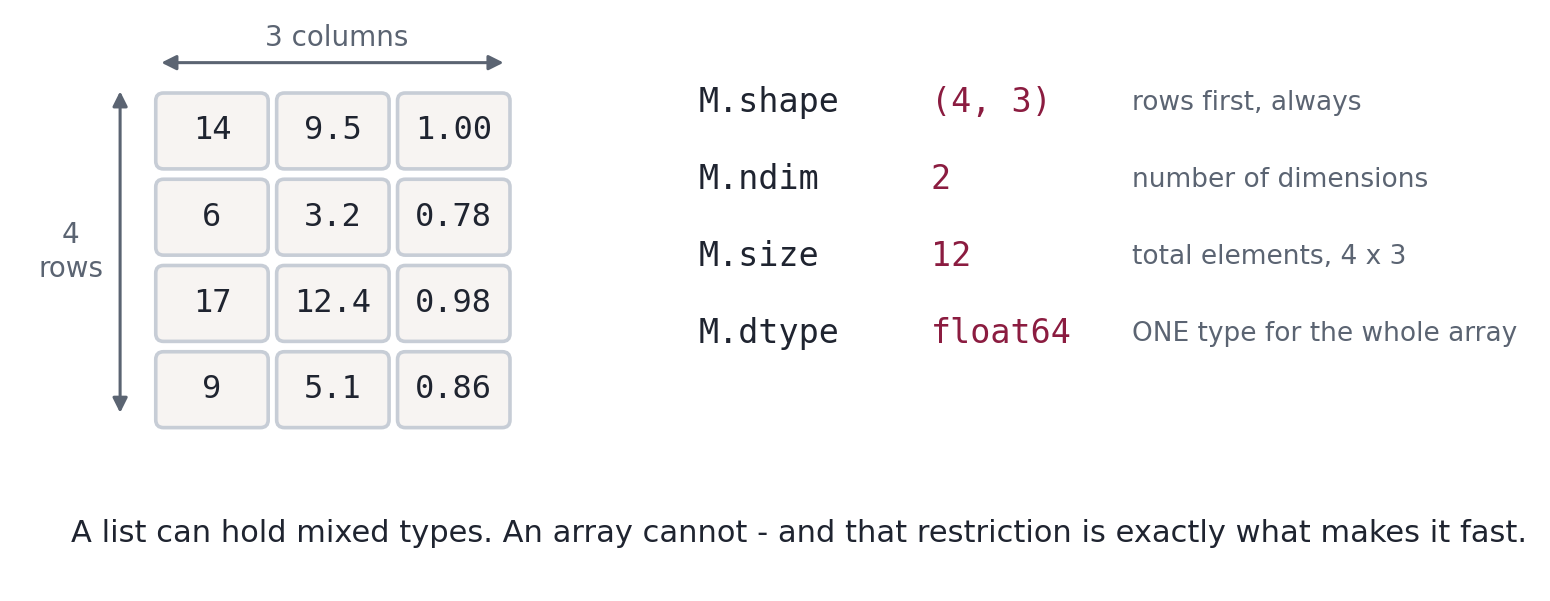

In [ ]:
print(f"shape  {logins.shape}")
print(f"ndim   {logins.ndim}")
print(f"size   {logins.size}")
print(f"dtype  {logins.dtype}")

`shape` is a tuple, which is why a one-dimensional array reports `(10,)` with the trailing comma - Module 2, section 8. On a 2D array all four get more interesting:

In [ ]:
M = np.array([[21, 30, 6, 7], [12, 13, 24, 41]])
print(f"shape  {M.shape}     <- (rows, columns)")
print(f"ndim   {M.ndim}")
print(f"size   {M.size}          <- 2 x 4")
print(f"dtype  {M.dtype}")

**Takeaway.** **When a NumPy operation surprises you, print the shape
first.** Not the values - the shape. The overwhelming majority of NumPy
confusion is a shape you assumed rather than checked, and `.shape` answers it in
one line.

This is the NumPy version of Module 2's advice to check `type()` when an
AttributeError shows up.

## dtype: one type for the whole array

A Python list can hold anything. An array holds **one type**, recorded in its
`dtype`, and that restriction is what makes the whole thing fast.

In [ ]:
print(np.array([1, 2, 3]).dtype)          # int64
print(np.array([1.0, 2.0, 3.0]).dtype)    # float64
print(np.array([True, False]).dtype)      # bool

> **Predict.** What dtype do you get from `np.array([1, 2, 3.5])` - a mix of ints and a float?
>
> Commit to an answer before you run the next cell.

In [ ]:
mixed = np.array([1, 2, 3.5])
print(mixed)
print(mixed.dtype)

**What happened.** `float64`, and look closely at the values: `1.` and `2.` have
gained decimal points.

NumPy **upcast** the integers to floats, because a float can represent an
integer without loss but not the reverse. It picks the type that holds
everything, silently.

Silently is the important word. Nothing warned you that your integer counts are
now floats.

Push it further and the result is worse:

In [ ]:
very_mixed = np.array([1, 2, "three"])
print(very_mixed)
print(very_mixed.dtype)

`<U21` means "Unicode string, up to 21 characters." **The numbers
became text.** Arithmetic on this array now fails, or worse, does something you
did not intend.

In [ ]:
%%expect TypeError
very_mixed * 2

**Takeaway.** A `dtype` of `<U...` on an array you expected to be numeric
means something non-numeric got in. In real data that is almost always a stray
`'N/A'`, `'--'`, or an empty string in a column of numbers.

Check `dtype` immediately after loading data. It is a five-second habit that
catches an entire category of bug before it propagates.

## Converting types

`.astype()` makes a new array with a different dtype:

In [ ]:
floats = np.array([1.9, 2.1, 3.7])
ints = floats.astype(np.int32)
print(floats)
print(ints)

**`.astype()` to an integer truncates, it does not round.** `1.9`
became `1`, and `3.7` became `3`. Same behavior as `int()` in Module 2. If you
want rounding, round first:

In [ ]:
print(np.round(floats).astype(np.int32))

## A dtype consequence you will hit in Module 4

Integer arrays have no way to represent a missing value. There is no bit pattern
for "absent" in an integer, so NumPy refuses:

In [ ]:
%%expect ValueError
counts = np.array([14, 6, 17])
counts[0] = np.nan

`cannot convert float NaN to integer`. The array has to be floats
before a `nan` can live in it:

In [ ]:
counts = np.array([14, 6, 17]).astype(float)
counts[0] = np.nan
print(counts)
print(np.isnan(counts))

**Takeaway.** **Missing data forces a numeric column to float.** An integer
count of logins with one value missing is no longer an integer column - it
becomes floats, and your counts start printing as `14.0`.

This is why real datasets are full of float columns that ought to be integers,
and it is the reason `np.isnan` raises a TypeError on an integer array: the
question is meaningless there. pandas has a nullable integer type that works
around it, which is one of the things Module 4 buys you.

### Your turn

The registrar sends a column of GPAs as text, the way a CSV would.

```python
raw = np.array(["3.81", "2.94", "3.55", "3.02"])
```

1. Print its dtype and confirm it is not numeric.
2. Show that arithmetic on it fails, or produces nonsense.
3. Convert it to a float array and compute the mean.

In [ ]:
raw = np.array(["3.81", "2.94", "3.55", "3.02"])

### ENTER CODE HERE ###

**Takeaway.** `raw + raw` is the dangerous case. It does not raise an
error - it **concatenates**, giving `'3.813.81'` instead of `7.62`. A silent
wrong answer is far worse than a crash, and this is exactly what happens when
two numeric columns arrive as text and somebody adds them.

Multiplication is less forgiving: in NumPy 2, `raw * 2` raises a `TypeError`
rather than repeating the text. Which operations fail loudly and which fail
quietly follows from the dtype, so check the dtype rather than memorizing a
table.

---
# 4 · Arithmetic and broadcasting

Every arithmetic operation you have written so far has been
between two things of the same size, or between an array and a single number.
Both worked, and neither needed explaining. That is about to stop being true.

Lee wants the three engagement measures combined into one index, and the
three sit on wildly different scales. Logins run from 4 to 17. Hours on task run
from 2.0 to 12.4. Submission rate runs from 0.61 to 1.00. Average those as they
stand and the answer is almost entirely a story about logins, because logins
produce the biggest numbers. The measure that dominates is the one with the
widest range, not the one that matters most, which is a poor reason for a number
to carry weight.

The standard fix is to rescale each measure onto a common 0-to-1 range before
combining them. For a single measure that is
`(x - x.min()) / (x.max() - x.min())`, which subtracts one number from an entire
array and then divides an entire array by another number. Applied to all three
measures at once, it subtracts *three* numbers, one per column, from a ten-row
table.

Neither of those is an operation between equal-sized things. Both work anyway.
The rule that makes them work is called **broadcasting**, and it is the part of
NumPy that most repays understanding properly. Get it right and array code reads
almost exactly like the formula it implements. Get it wrong and you meet
`ValueError: operands could not be broadcast together`, which is the error you
will see more than any other while learning this library.

You have in fact already relied on broadcasting three times in this notebook
without it being named. This section names it. It starts with the easy case
where shapes match exactly, shows what NumPy does when they do not, states the
rule precisely, and then applies it to the cohort.

## Element-wise arithmetic

Two arrays of the same shape combine position by position.

In [ ]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print(a + b)
print(b - a)
print(a * b)
print(b / a)

Note `a * b`: that's `[1*10, 2*20, ...]`, **not** matrix
multiplication. NumPy's `*` is element-wise. Matrix multiplication is `@`, which
you will not need in this course but should recognize.

All the comparison operators work element-wise too, and return an array of
booleans:

In [ ]:
print(a > 2)
print(b == 20)

Hold onto that - an array of booleans is how you filter data, in section 8.

## Broadcasting

So what happens when the shapes **don't** match?

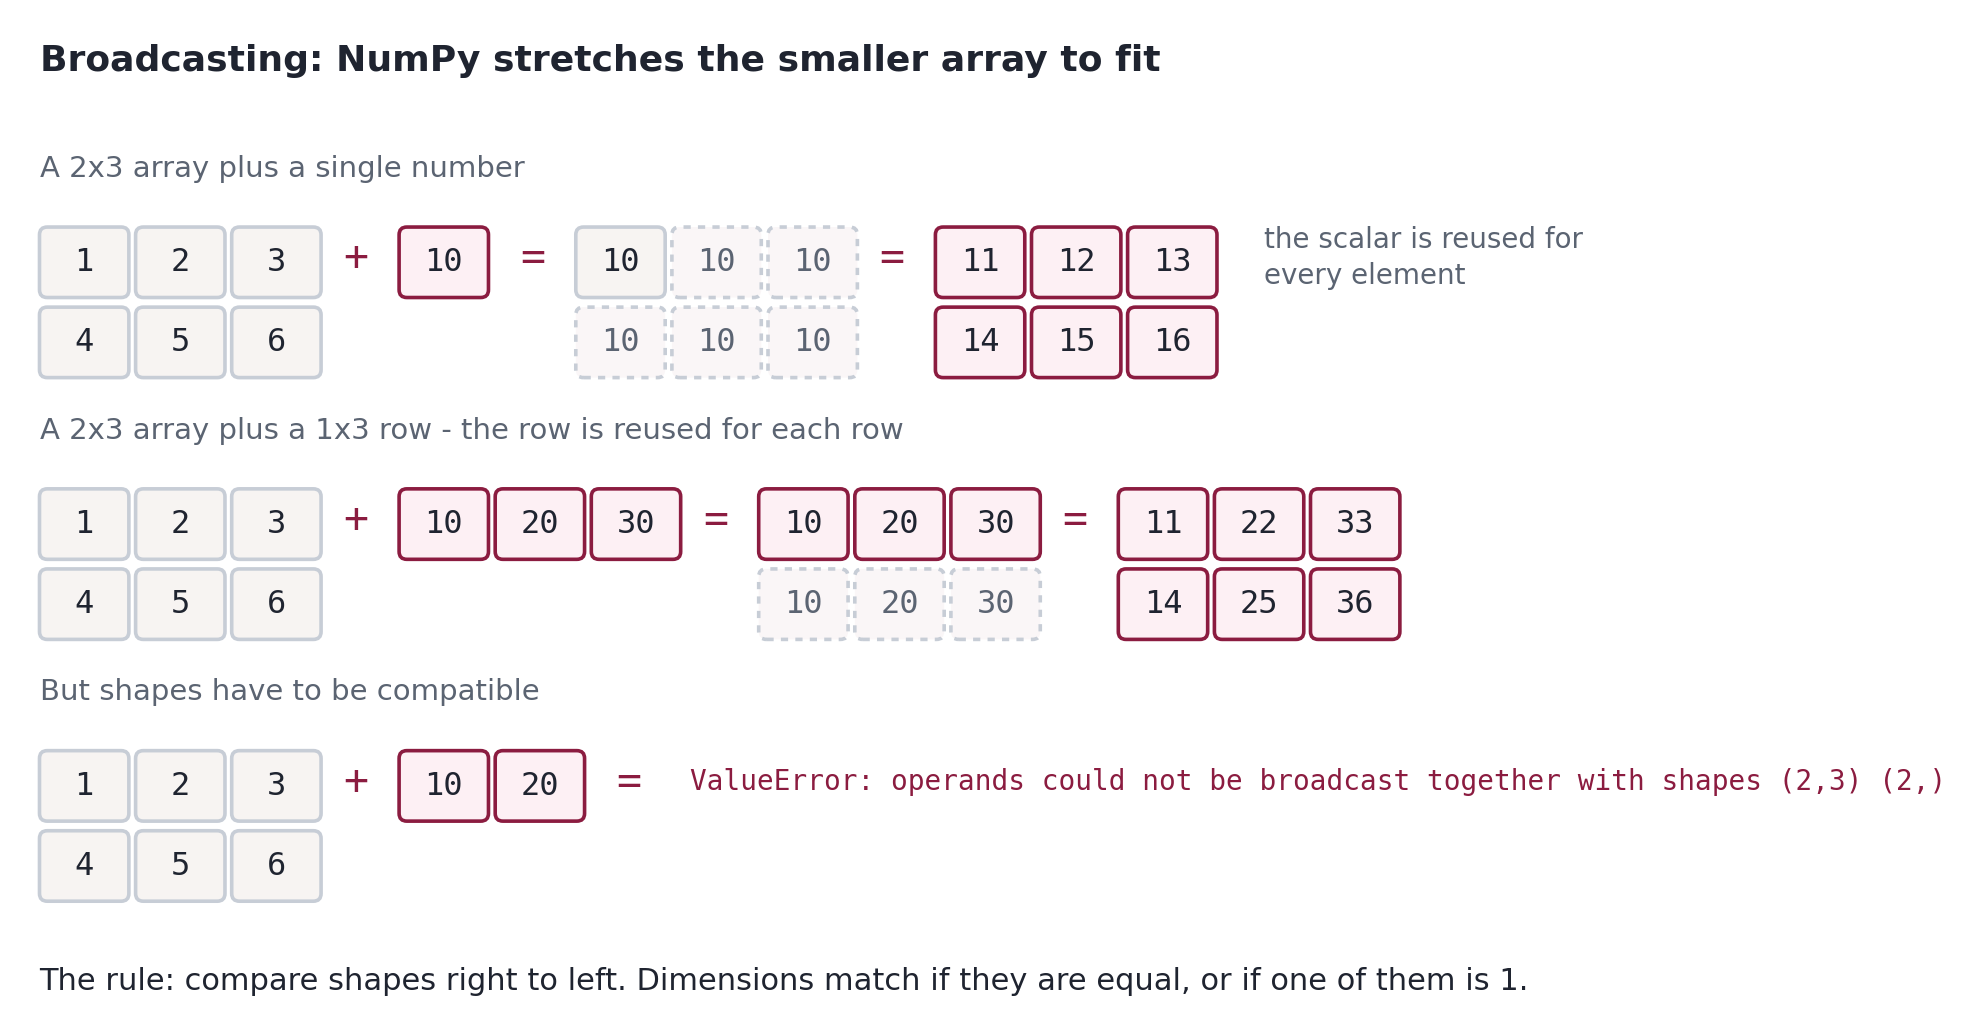

In [ ]:
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print(M + 10)

The single number was applied to all six elements. NumPy did not
build a 2-by-3 array of tens - it just reused the value, which costs nothing.

Now a row:

In [ ]:
row = np.array([10, 20, 30])
print(f"M.shape   = {M.shape}")
print(f"row.shape = {row.shape}")
print()
print(M + row)

The row was reused for each of the two rows of `M`. Column 0 got
`10`, column 1 got `20`, column 2 got `30`.

**The rule.** Compare the shapes from the right. Two dimensions are compatible
if they are equal, or if one of them is `1`:

```
M     (2, 3)
row      (3,)      ->  the 3s match, and M's leading 2 is free
result (2, 3)
```

And when they aren't compatible, NumPy refuses:

> **Predict.** `M` is shape (2, 3). What happens with `M + np.array([10, 20])` - a 2-element array?
>
> Commit to an answer before you run the next cell.

In [ ]:
%%expect ValueError
M + np.array([10, 20])

**What happened.** A `ValueError`, and the message is one to memorize:
`operands could not be broadcast together with shapes (2,3) (2,)`.

Reading right to left: `3` against `2`. Not equal, neither is `1`, so there is
no way to line them up. NumPy will not guess.

You might reasonably have expected this to work - `M` has two rows and the array
has two elements, so surely one per row? That is a natural thought and it is
wrong, because broadcasting aligns from the **right**, not the left. To get the
per-row behavior you have to say so explicitly:

In [ ]:
col = np.array([10, 20]).reshape(2, 1)     # an explicit column
print(f"col.shape = {col.shape}")
print(col)
print()
print(M + col)

Now the shapes are `(2, 3)` and `(2, 1)`. Right to left: `3`
against `1` - one of them is 1, so it stretches. Then `2` against `2` - equal.
Compatible.

`np.newaxis` does the same job and reads more clearly once you're used to it:

In [ ]:
col = np.array([10, 20])[:, np.newaxis]
print(col.shape)

# np.newaxis IS None -- these three are the same thing
print(np.newaxis is None)
print(np.array([10, 20])[:, None].shape)

`np.newaxis` and `None` are literally the same object, so
`a[:, None]` and `a[:, np.newaxis]` are identical. You will see **both** in the
wild: `np.newaxis` is more self-documenting, `[:, None]` is shorter and very
common in library source code and on Stack Overflow. Learn to read both.

**Takeaway.** **When you get a broadcast ValueError, print both shapes and
line them up from the right.** The fix is almost always to reshape one operand
so the dimensions align the way you meant.

The error message already contains both shapes. Read it instead of guessing.

## Why this matters for the cohort

Lee wants an engagement index that combines logins, hours, and submission
rate. Those three are on completely different scales - logins run 4 to 17, hours
run 2.0 to 12.4, submission is 0.61 to 1.00. Averaging them directly would let
logins dominate purely because its numbers are bigger.

The fix is to **normalize** each measure to a 0-to-1 range first:

$$\text{normalized} = \frac{x - \min(x)}{\max(x) - \min(x)}$$

Here it is on one measure. Every operation below is broadcasting a single number
across a 10-element array:

In [ ]:
norm_logins = (logins - logins.min()) / (logins.max() - logins.min())
print(np.round(norm_logins, 3))
print(f"min {norm_logins.min()}, max {norm_logins.max()}")

The lowest value maps to 0, the highest to 1, everything else in
between. No loop, three operations, and it reads almost exactly like the
formula.

You will do this for all three measures at once in the final challenge, using
`axis` from section 11. That's the engagement index.

Three things are worth carrying out of this section.

**The rule.** Compare shapes from the right. Two dimensions are compatible when
they are equal, or when one of them is 1. Nothing else is compatible, and NumPy
will not guess on your behalf.

**The direction.** Broadcasting aligns shapes from the right, not the left,
which is why a 2-by-3 array and a 2-element array refuse to combine even though
"2" appears in both. When you want per-row behavior you have to ask for it,
either by reshaping to a column or by inserting an axis with `np.newaxis`. This
is the most common broadcasting mistake, and it is usually not a
misunderstanding of the rule so much as an expectation that it works the other
way round.

**Why it matters beyond convenience.** Broadcasting is what lets a formula
written for one value apply unchanged to a whole table. The engagement index you
will build in section 11 is four lines long, and it would be four lines whether
the cohort held ten students or eighty thousand. Typing less is the smallest part of it. Code like that expresses the idea instead of burying it in bookkeeping.

When a shape error does appear, remember that the message contains both shapes.
Print them, line them up from the right, and the fix is almost always a reshape
on one operand.

### Your turn

1. `hs_gpa` and `ug_gpa` are both 10-element arrays. Compute each student's GPA
   change from high school to undergrad, and print the mean change.
2. Convert `hours` from hours per week to **minutes** per week.
3. Center `ug_gpa` on its own mean - subtract the mean from every value. What
   should the mean of the result be? Check it.

In [ ]:
### ENTER CODE HERE ###

---
# 5 · Indexing and slicing

For one-dimensional arrays, everything you learned about lists in Module 2
applies without change. Zero-based, negative indices count from the end, slices
exclude the stop.

In [ ]:
print(logins[0])        # first student
print(logins[-1])       # last student
print(logins[2:5])      # a slice
print(logins[:3])       # from the beginning
print(logins[::2])      # every other one

`::2` is the **step**, the third part of a slice. `[start:stop:step]`. It works on lists too, and it's how you reverse a sequence:

In [ ]:
print(logins[::-1])

## Two dimensions

Here is where arrays part company with lists. Let's build a matrix of the three
engagement measures, one student per row.

In [ ]:
# np.column_stack puts each array in as a column
engagement = np.column_stack([logins, hours, submission])
print(f"shape: {engagement.shape}")
print(engagement[:4])       # first four students

Ten rows, three columns. Column 0 is logins, column 1 is hours,
column 2 is submission rate.

With a list of lists you would reach an element with `data[2][0]`. NumPy accepts
that, but the idiomatic form uses **one** set of brackets with a comma:

In [ ]:
print(engagement[2][0])     # works, but not idiomatic
print(engagement[2, 0])     # row 2, column 0 -- this is the NumPy way

Row first, then column. Always the same order as `shape`. A single index gives you a whole row:

In [ ]:
print(engagement[0])        # everything about student 0
print(engagement[0].shape)

And a slice in either position selects a whole column or a block:

In [ ]:
print(engagement[:, 0])     # every row, column 0 -> all the logins
print(engagement[:, 1])     # all the hours

> **Predict.** What shape does `engagement[:3, :2]` have, and what does it contain?
>
> Commit to an answer before you run the next cell.

In [ ]:
block = engagement[:3, :2]
print(block)
print(f"shape: {block.shape}")

**What happened.** Shape `(3, 2)` - the first three students, their logins and
hours only.

Two slices give you a rectangular block. The mental model that helps: read the
comma as "and then." *Rows 0 through 2, and then columns 0 through 1.*

`:` on its own means everything along that axis, which is why `engagement[:, 0]` reads as *all rows, column zero*.

In [ ]:
%%expect IndexError
engagement[10, 0]

Ten students means valid row indices `0` through `9`. NumPy's
message names the axis and the size, which is more helpful than the list version
in Module 2: `index 10 is out of bounds for axis 0 with size 10`.

### Your turn

Using `engagement` (10 rows: logins, hours, submission):

1. Print the full record for Priya Raghunathan, who is at index 2.
2. Print the submission rates for the last three students.
3. Print a block containing the first five students' logins and hours.
4. Print every student's hours, in reverse order.

In [ ]:
### ENTER CODE HERE ###

---
# 6 · Views and copies

A short section with an outsized capacity to ruin an afternoon.

In Module 2 you learned that `backup = scores` does not copy a list - both names
refer to the same object. Arrays have that behavior too, **and one more**:
slicing an array does not copy either.

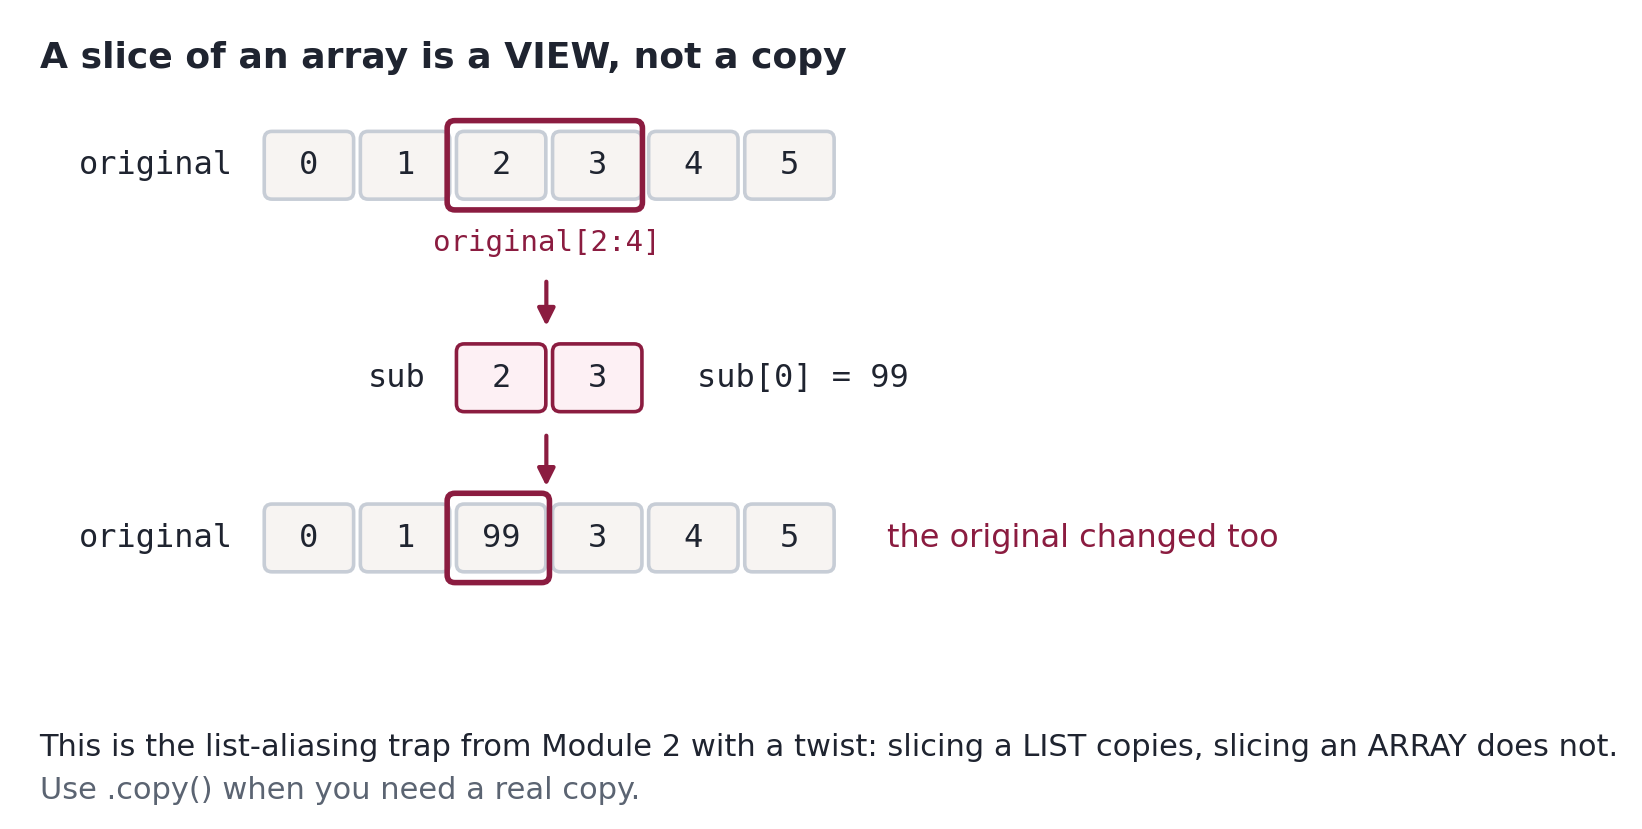

> **Predict.** `sub` is a slice of `original`. After `sub[0] = 99`, what does `original` contain?
>
> Commit to an answer before you run the next cell.

In [ ]:
original = np.arange(6)
print(f"original: {original}")

sub = original[2:4]
print(f"sub:      {sub}")

sub[0] = 99
print()
print(f"sub is now:      {sub}")
print(f"original is now: {original}")

**What happened.** `original` changed to `[0 1 99 3 4 5]`.

`sub` is a **view** - a window onto the same memory, not a new array. Writing
through the window writes to the original.

This differs from lists, and the difference is easy to miss:

```python
lst = [0, 1, 2, 3]
part = lst[1:3]     # a COPY. changing part leaves lst alone

arr = np.arange(4)
part = arr[1:3]     # a VIEW. changing part changes arr
```

NumPy works this way on purpose. Slicing a million-row array without copying it
is instant and free; copying would cost time and memory every time you looked at
a subset. The default is the one that scales.

When you genuinely want independent data, ask for it:

In [ ]:
original = np.arange(6)
safe = original[2:4].copy()
safe[0] = 99

print(f"safe:     {safe}")
print(f"original: {original}")

`np.may_share_memory` will tell you which situation you're in, and it's a useful debugging tool:

In [ ]:
a = np.arange(6)
print(np.may_share_memory(a, a[2:4]))          # a view
print(np.may_share_memory(a, a[2:4].copy()))   # a copy

**Takeaway.** **Slicing an array gives a view. Slicing a list gives a copy.**

If you are about to modify a subset and you need the original intact, call
`.copy()`. If you're only reading, take the view - it's free.

The symptom of getting this wrong is data that changes when you didn't change
it, usually noticed several cells later when a number doesn't reconcile.

### Your turn

Predict each result before running. This is the trap in its most common
real-world form: a function that "cleans" a subset and quietly corrupts the
source.

```python
scores = np.array([88, 92, 79, 93, 85])

def cap_at_90(data):
    subset = data[:3]
    subset[subset > 90] = 90
    return subset

capped = cap_at_90(scores)
print(capped)
print(scores)
```

What does `scores` look like afterwards? Then fix `cap_at_90` so it leaves the
input alone.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** A function that modifies the array it was handed has a **side
effect**, and side effects are how debugging sessions turn into archaeology.

Returning a **view** rather than a copy is the same hazard one step removed: the
caller gets something that looks like fresh data and is secretly wired back to
the original. In a multi-step pipeline that is among the most common causes of
data changing when nothing appears to have changed it, and it is hard to find
afterwards because the code that caused it looks entirely reasonable.

Unless the function's whole job is to modify something in place, copy first.
Module 2 said functions should return rather than print; the array version is
that functions should return new data rather than mutate their inputs.

---
# 7 · Reshaping, stacking, splitting

Data rarely arrives in the shape you need. These operations change the shape
without changing the values.

## reshape

`reshape` rearranges the same elements into different dimensions.

In [ ]:
counts = np.arange(12)
print(counts)
print()
print(counts.reshape(3, 4))
print()
print(counts.reshape(4, 3))

The element **count** has to match. Twelve elements can be 3x4 or 4x3 or 2x6, but not 5x3:

In [ ]:
%%expect ValueError
counts.reshape(5, 3)

`cannot reshape array of size 12 into shape (5,3)` - the message does the arithmetic for you.

`-1` means *work it out yourself*, which saves you doing the division:

In [ ]:
print(counts.reshape(3, -1).shape)     # 3 rows, however many columns that needs
print(counts.reshape(-1, 2).shape)     # 2 columns, however many rows

**Takeaway.** `reshape(-1, n)` is the form you'll use most: *n columns,
whatever number of rows that implies*. It keeps working when the row count
changes, which is the whole point - the same code handles ten students and
eighty thousand.

## Stacking

Module 2 built the cohort as separate lists. Here we combine separate arrays
into one matrix, which is what the engagement index needs.

`np.column_stack` treats each array as a column:

In [ ]:
engagement = np.column_stack([logins, hours, submission])
print(f"shape {engagement.shape}")
print(engagement[:3])

`np.vstack` stacks arrays as rows, and `np.hstack` joins them end to end:

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("vstack:")
print(np.vstack([a, b]))
print()
print("hstack:", np.hstack([a, b]))

> **Predict.** `np.hstack([a, b])` gave a 6-element array. What shape does `np.vstack([a, b])` give?
>
> Commit to an answer before you run the next cell.

In [ ]:
print(np.vstack([a, b]).shape)

**What happened.** `(2, 3)` - two rows of three.

`hstack` extends along the existing axis, keeping it one-dimensional. `vstack`
adds a dimension. The names are about direction, not about dimensionality, which
is why people mix them up. If you need to be sure, print the shape.

`np.concatenate` does both, with an explicit `axis`, and once you understand
`axis` in section 11 it's often the clearer choice.

In [ ]:
M = np.array([[1, 2], [3, 4]])
N = np.array([[5, 6], [7, 8]])
print(np.concatenate([M, N], axis=0))    # stack rows -> (4, 2)
print()
print(np.concatenate([M, N], axis=1))    # stack columns -> (2, 4)

## Splitting

`np.split` cuts an array at given positions:

In [ ]:
season = np.arange(12)
first_half, second_half = np.split(season, [6])
print(first_half)
print(second_half)

The list `[6]` is where to cut, not how many pieces. Give more positions for more pieces:

In [ ]:
q1, q2, q3, q4 = np.split(season, [3, 6, 9])
print(q1, q2, q3, q4)

### Your turn

1. Take `np.arange(20)` and reshape it into 4 rows without computing the column
   count yourself.
2. Stack `hs_gpa` and `ug_gpa` into a 10-by-2 array where each row is one
   student.
3. From that array, print only the students whose row index is even, using a
   step slice.

In [ ]:
### ENTER CODE HERE ###

---
# 8 · Boolean indexing, and checking your data

This is the section that changes how you work. Filtering with booleans replaces
almost every `if` inside a loop you wrote in Module 2.

## A comparison produces an array of booleans

In [ ]:
print(logins)
print(logins > 12)

One `True` or `False` per element. That array is called a **mask**,
and on its own it isn't very interesting. What makes it powerful is using it as
an index.

In [ ]:
mask = logins > 12
print(logins[mask])

**Only the elements where the mask was `True` came back.** No loop,
no `if`, no accumulator list.

Usually it's written in one line:

In [ ]:
print(logins[logins > 12])

And because the arrays line up by position, a mask from one measure filters another:

In [ ]:
engaged = logins > 12
print(f"names:  {names[engaged]}")
print(f"GPAs:   {ug_gpa[engaged]}")

That is the whole idea. **Build a mask from one column, apply it to
another.** Nearly every filtering question in pandas is this same move with
nicer syntax.

Compare it to the Module 2 version:

```python
# Module 2
result = []
for i, n in enumerate(logins):
    if n > 12:
        result.append(names[i])

# Module 3
result = names[logins > 12]
```

## Combining conditions

Here is a trap that catches everyone once. Python's `and` / `or` do **not**
work on arrays:

In [ ]:
%%expect ValueError
logins[(logins > 12) and (ug_gpa > 3.5)]

`The truth value of an array with more than one element is
ambiguous` means NumPy was asked whether a ten-element array is "true" and
cannot answer.

Use `&` for and, `|` for or, `~` for not. **And parenthesize each condition**,
because `&` binds more tightly than `>`:

In [ ]:
high_both = (logins > 12) & (ug_gpa > 3.5)
print(f"engaged AND high GPA: {names[high_both]}")

either = (logins > 15) | (ug_gpa > 3.85)
print(f"very engaged OR very high GPA: {names[either]}")

not_engaged = ~(logins > 12)
print(f"not engaged: {names[not_engaged]}")

**Takeaway.** **`&` `|` `~`, with parentheses around every condition.**

`and` / `or` / `not` are for single true-or-false values. `&` / `|` / `~` are
element-wise. Forgetting the parentheses gives a confusing error rather than a
wrong answer, which is at least merciful.

This carries directly into pandas, where the syntax is identical.

## Counting and checking

A boolean array answers questions about itself. Since `True` counts as 1, `sum`
counts matches:

In [ ]:
print(f"students with more than 12 logins: {(logins > 12).sum()}")
print(f"proportion: {(logins > 12).mean():.0%}")

`.mean()` on a boolean array gives the **proportion** that are true, which is a genuinely useful trick.

## any and all

Two methods that belong in every data-quality check you write.

In [ ]:
print(f"is ANY submission rate below 0.7?   {(submission < 0.7).any()}")
print(f"are ALL submission rates above 0.5?  {(submission > 0.5).all()}")

`.any()` asks whether at least one element is true. `.all()` asks
whether every one is. Both collapse a whole array to a single `True` or `False`,
which means they slot straight into an `if`.

In [ ]:
def check_engagement_data(logins, hours, submission):
    """Report anything obviously wrong before we compute an index from these."""
    problems = []

    if (logins < 0).any():
        problems.append("negative login counts")
    if (hours < 0).any():
        problems.append("negative hours")
    if not ((submission >= 0) & (submission <= 1)).all():
        problems.append("submission rate outside 0-1")
    if np.isnan(logins).any() or np.isnan(hours).any():
        problems.append("missing values")

    if problems:
        for p in problems:
            print(f"  PROBLEM: {p}")
    else:
        print("  all checks passed")


print("Engagement data check:")
check_engagement_data(logins, hours, submission)

That function is Capstone Stage 3's data-quality requirement, and
it is six lines. Run it before you compute anything, every time.

Now watch it earn its keep on data that is subtly wrong:

In [ ]:
bad_submission = submission.copy()
bad_submission[3] = 1.4        # a rate above 100%, which cannot be right

print("Check on corrupted data:")
check_engagement_data(logins, hours, bad_submission)

**Takeaway.** **`.any()` and `.all()` turn an assumption into a check.**

Every time you think "these should all be positive" or "there shouldn't be any
missing," that sentence translates directly into one line of code. Writing it
down costs seconds and catches the class of error that otherwise surfaces as an
implausible number in a report to a Cabinet.

## Assigning through a mask

A mask can appear on the left of an assignment, which replaces only the selected
elements:

In [ ]:
capped = submission.copy()
capped[capped > 0.95] = 0.95
print(submission)
print(capped)

Note the `.copy()`. Section 6 explains what happens without it.

### Your turn

Using the cohort arrays:

1. How many students have a submission rate of at least 0.9?
2. Print the names of students who are **below** the mean on both logins and
   hours.
3. Check whether any student has a `ug_gpa` above 4.0, which would be impossible.
4. Print the mean `ug_gpa` of students with more than 12 logins, and of those
   with 12 or fewer. What do you notice, and what would you be careful about
   claiming?

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** That last comparison shows a gap of roughly half a GPA point,
and it is exactly the kind of number that ends up in a slide deck without its
caveats.

With five students in each group, no controls, and a split point we chose
ourselves after looking at the data, this is a hypothesis and not a finding.
Notice in particular that we picked the threshold of 12 because it was
convenient. Choosing a cut point after seeing the data is one of the easiest
ways to manufacture a result that will not replicate.

---
# 9 · Fancy indexing

A short section. Passing a **list of indices** pulls out exactly those elements,
in exactly that order.

In [ ]:
print(logins[[0, 3, 7]])          # students 0, 3 and 7
print(names[[7, 3, 0]])           # order is yours to choose

This is called **fancy indexing**, and it differs from slicing in
two ways worth knowing: the positions don't have to be contiguous or in order,
and it returns a **copy**, not a view.

In [ ]:
a = np.arange(6)
print(np.may_share_memory(a, a[2:4]))        # slice -> view
print(np.may_share_memory(a, a[[2, 3]]))     # fancy -> copy

It combines naturally with the sorting in section 12 - take the indices of the top three, then use them to pull names:

In [ ]:
top3 = np.argsort(ug_gpa)[-3:][::-1]     # indices of the 3 highest GPAs
print(f"indices: {top3}")
print(f"names:   {names[top3]}")
print(f"GPAs:    {ug_gpa[top3]}")

### Your turn

1. Print the names and login counts of students at indices 1, 5, and 9.
2. Using `np.argsort`, print the three **least** engaged students by logins,
   with their names.
3. Confirm that fancy indexing returns a copy: take `sub = logins[[0, 1]]`,
   change `sub[0]`, and show `logins` is unaffected.

In [ ]:
### ENTER CODE HERE ###

---
# 10 · Universal functions

A **ufunc** is a function that operates element-wise on an array. You've been
using them since section 4 - `+`, `*` and `>` are all ufuncs wearing operator
costumes.

The named ones cover the mathematics you'd otherwise loop for.

In [ ]:
x = np.array([1, 4, 9, 16, 25])

print(np.sqrt(x))
print(np.log(x).round(3))
print(np.exp([0, 1, 2]).round(3))
print(np.abs([-3, -1, 2]))

Rounding has three variants worth telling apart:

In [ ]:
vals = np.array([1.4, 1.5, 2.5, -1.5])
print(f"round: {np.round(vals)}")     # to even on .5, as in Module 2
print(f"floor: {np.floor(vals)}")     # always down
print(f"ceil:  {np.ceil(vals)}")      # always up

**Binary** ufuncs take two arrays and combine them element-wise:

In [ ]:
a = np.array([1, 5, 3])
b = np.array([4, 2, 6])

print(np.maximum(a, b))     # larger of each pair
print(np.minimum(a, b))     # smaller of each pair

> **Predict.** `np.maximum(a, b)` returns an array. What does `np.max(a)` return, and how is it different?
>
> Commit to an answer before you run the next cell.

In [ ]:
print(f"np.maximum(a, b) = {np.maximum(a, b)}")
print(f"np.max(a)        = {np.max(a)}")

**What happened.** `np.maximum` is a **binary ufunc**: it compares two arrays
element by element and returns an array the same shape.

`np.max` is an **aggregate**: it reduces one array to a single value.

The names are one letter apart and the behaviors are unrelated. `maximum` for
pairwise, `max` for the biggest. Section 11 is all about aggregates.

## Ufuncs and missing values

The cohort's `grad_gpa` has a `np.nan` in it - Marcus Webb, still enrolled.
Watch what ufuncs do with it.

In [ ]:
print(grad_gpa)
print(grad_gpa + 1)

`nan` stayed `nan`. That's the defining property: **`nan`
propagates.** Any arithmetic touching it produces `nan`, which means one missing
value can silently poison an entire calculation.

> **Predict.** What does `grad_gpa.mean()` give, with one nan among ten values?
>
> Commit to an answer before you run the next cell.

In [ ]:
print(grad_gpa.mean())

**What happened.** `nan`. Not the mean of the nine real values - `nan`.

This is exactly right and completely unhelpful. NumPy is refusing to guess what
the missing value should have been, which is honest, but it means your summary
statistic is now unusable.

Note also that this is a **silent** failure in the sense that matters: no error,
no warning, just a result that is wrong if you don't look at it. If a report
prints `nan` you'll notice. If it feeds into another calculation first, you may
not.

NumPy provides `nan`-aware versions of the aggregates, which skip missing values:

In [ ]:
print(f"mean  {grad_gpa.mean()}")
print(f"nanmean {np.nanmean(grad_gpa):.4f}")
print(f"nanmax  {np.nanmax(grad_gpa)}")
print(f"count of non-missing: {(~np.isnan(grad_gpa)).sum()}")

`np.isnan` gives a mask, so `~np.isnan(x)` is the mask of values that are present. That's the connection back to section 8.

**Takeaway.** **`nan` is not zero and it is not an error - it propagates.**

`np.nanmean` and friends skip missing values, which is convenient and is also a
decision you are making on the analyst's behalf. Dropping the missing value here
means the graduate GPA average describes only students who have finished. That
may be exactly right, or it may bias the number - and either way it belongs in
the caveats, not buried in a function name.

Module 4 handles this properly. For now: know that it happened.

### Your turn

1. Compute the square root of `hours` and round it to two decimals.
2. Use `np.maximum` to cap every login count at 12.
3. Compute the mean of `grad_gpa` two ways - once ignoring the problem, once
   with `np.nanmean` - and state in a comment which you'd report to Lee and
   why.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** Exercise 2 has a trap worth noticing: `np.maximum(logins, 12)`
raises everything *up* to 12, which is the opposite of capping. To impose a
ceiling you want `np.minimum`.

The names describe what the function returns, not what it does to your data. If
that feels backwards, you are not alone - read them as "give me the larger of
each pair" and "give me the smaller.

---
# 11 · Aggregation and axis

An **aggregate** collapses many values into one. You know several already.

In [ ]:
print(f"sum    {logins.sum()}")
print(f"mean   {logins.mean():.2f}")
print(f"min    {logins.min()}")
print(f"max    {logins.max()}")
print(f"std    {logins.std():.3f}")
print(f"median {np.median(logins)}")

### One number that will change under you in Module 4

`std` has a parameter, `ddof`, that decides what you divide by. NumPy defaults to
`ddof=0` - the **population** standard deviation, dividing by n. pandas defaults
to `ddof=1` - the **sample** standard deviation, dividing by n-1.

In [ ]:
print(f"numpy default (ddof=0): {logins.std():.6f}")
print(f"numpy with ddof=1:      {logins.std(ddof=1):.6f}")
print(f"difference:             {logins.std(ddof=1) - logins.std():.6f}")

**Takeaway.** **`np.std()` and `pandas.Series.std()` give different answers
on the same data, by default.** NumPy divides by n, pandas divides by n-1.

Neither is wrong. n-1 corrects for the fact that a sample's spread tends to
underestimate the population's, so it is the right default when your data is a
*sample* of something larger - which, for our cohort, it is. NumPy's default
suits you when the data *is* the whole population.

This will bite you in Module 4 when a standard deviation changes for no apparent
reason. Now you'll know why. If it matters, pass `ddof` explicitly in both
libraries rather than relying on either default.

Note the two calling styles: `logins.sum()` is a method on the
array, `np.median(logins)` is a function. Most aggregates offer both;
`median` happens to be function-only. If `.something()` doesn't exist, try
`np.something()`.

`argmin` and `argmax` give the **position** of the extreme value rather than the
value, which is how you find out *who*:

In [ ]:
busiest = logins.argmax()
print(f"index {busiest}: {names[busiest]} with {logins[busiest]} logins")

## axis: which direction the collapse runs

On a 2D array, an aggregate can collapse the whole thing, or work down the
columns, or across the rows.

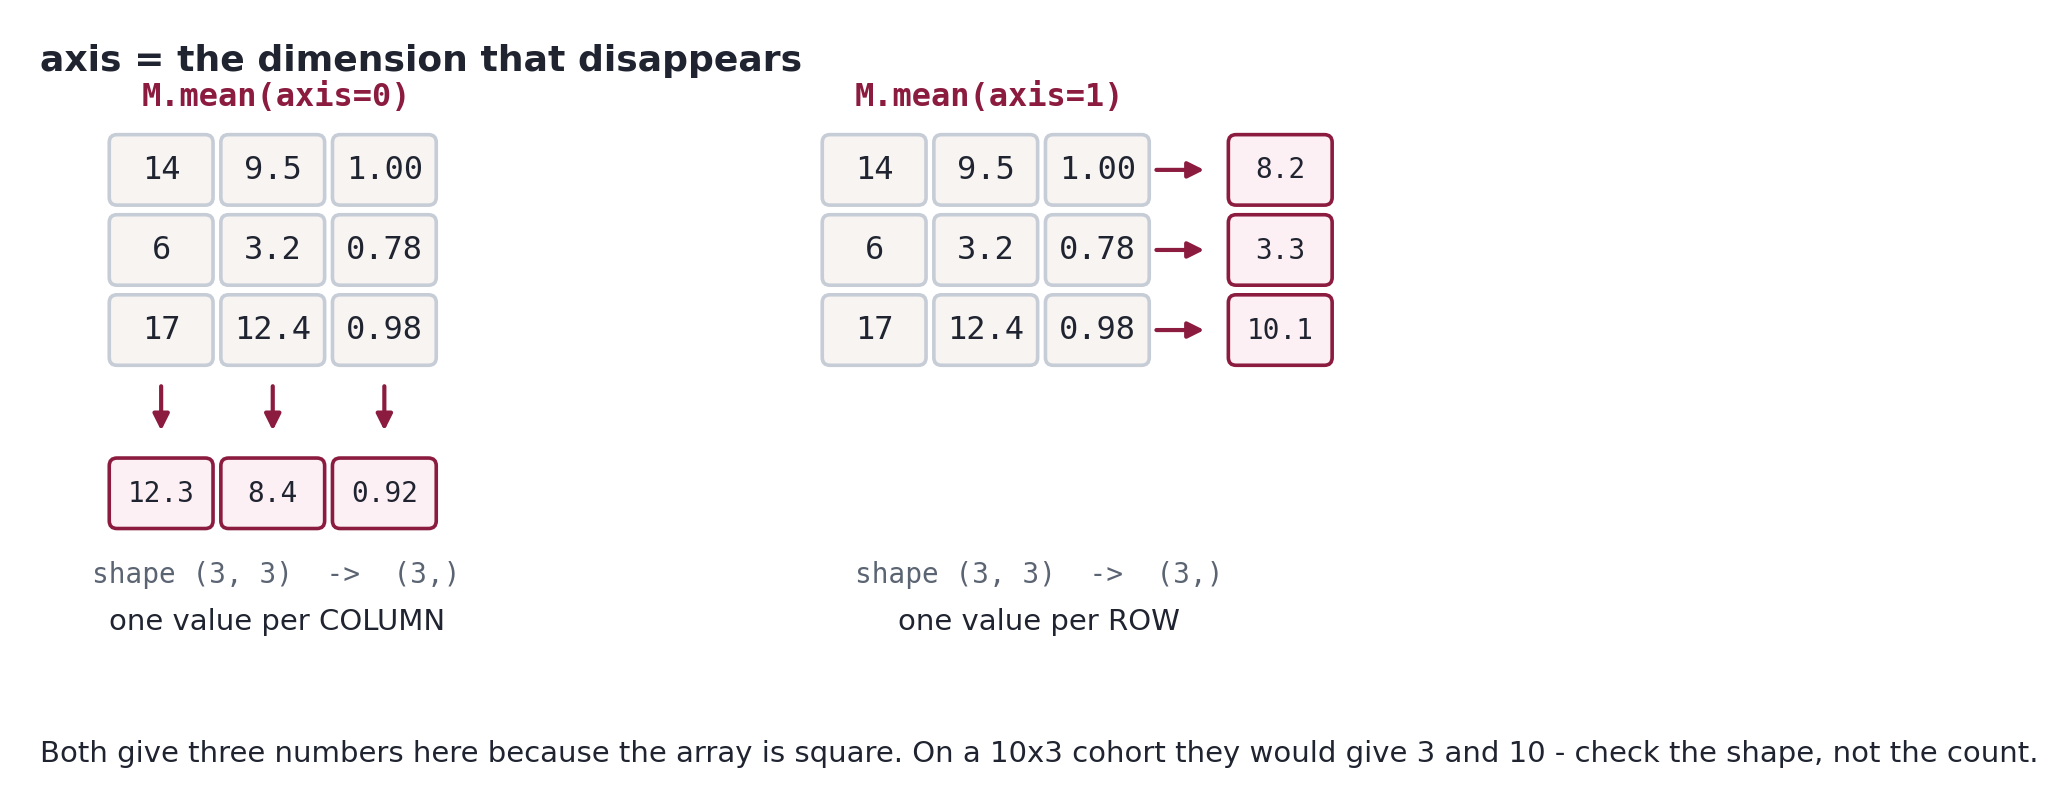

In [ ]:
engagement = np.column_stack([logins, hours, submission])
print(f"shape {engagement.shape}\n")

print(f"everything:  {engagement.mean():.3f}")
print(f"axis=0:      {engagement.mean(axis=0).round(3)}")
print(f"axis=1:      {engagement.mean(axis=1).round(3)}")

With no `axis`, you get one number for all thirty values - which
here is meaningless, since it averages logins with submission rates.

`axis=0` gave **three** numbers: the mean logins, mean hours, and mean
submission across all students. One per column.

`axis=1` gave **ten**: one per student. Also meaningless here, for the same
mixing-units reason, but the shape is what matters.

> **Predict.** `engagement` is shape (10, 3). What shape does `engagement.sum(axis=0)` have - (10,) or (3,)?
>
> Commit to an answer before you run the next cell.

In [ ]:
print(f"axis=0 -> {engagement.sum(axis=0).shape}")
print(f"axis=1 -> {engagement.sum(axis=1).shape}")

**What happened.** `axis=0` gives shape `(3,)` and `axis=1` gives `(10,)`.

The reliable way to think about it: **`axis` names the dimension that
disappears.** `axis=0` is the row dimension, so the rows collapse and you're
left with one value per column.

Almost everyone's first instinct is the opposite - that `axis=0` means "give me
rows." Check the shape until the correct version becomes automatic.

**Takeaway.** **`axis=0` collapses rows and gives you one value per column.**
That is the one you want for per-measure summaries, and it is the one you'll use
for the engagement index.

Say it out loud when you write it: *"axis zero, columns survive."*

## Building the engagement index

Now everything comes together. Lee wants logins, hours, and submission
combined into one comparable number, and the three are on different scales.

Normalize each **column** to 0-1, then average across the three.

In [ ]:
col_min = engagement.min(axis=0)      # 3 values, one per measure
col_max = engagement.max(axis=0)

print(f"minimums: {col_min}")
print(f"maximums: {col_max}")
print(f"shapes:   {engagement.shape} and {col_min.shape}")

`engagement` is `(10, 3)` and `col_min` is `(3,)`. Compare from the
right: 3 against 3, they match. So this broadcasts - the same three minimums are
subtracted from every one of the ten rows. That's section 4 doing real work.

In [ ]:
normalized = (engagement - col_min) / (col_max - col_min)

print(np.round(normalized[:4], 3))
print()
print(f"column minimums now: {normalized.min(axis=0)}")
print(f"column maximums now: {normalized.max(axis=0)}")

In [ ]:
engagement_index = normalized.mean(axis=1)      # average the 3 measures

for i in np.argsort(engagement_index)[::-1]:
    print(f"{names[i]:20} {engagement_index[i]:.3f}")

There it is. One number per student, comparable across students,
built from three measures on different scales - and the whole computation is
four lines that would work identically on eighty thousand rows.

### Your turn

1. Using `axis`, compute the mean `hs_gpa` and mean `ug_gpa` in a single call,
   by stacking them first.
2. Which student has the largest gap between their normalized login score and
   their normalized submission score? Use `argmax` on the difference.
3. The index above weights all three measures equally. Recompute it weighting
   submission rate double, and see whether the ranking changes. Should it be
   equally weighted? That is a judgment call, not a technical one - say what
   you'd tell Lee.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** The weighting question has no technical answer, and that is the
point.

Equal weights are a choice. They say a login is worth as much as a submitted
assignment, which is almost certainly false but is at least transparent.
Weighting submission double is also a choice, and it needs a justification other
than that it produced a nicer-looking ranking.

Whatever you pick, **state the weights in the report**. An index whose weights
are undocumented is a number nobody can argue with, which sounds like a strength
and is actually the problem.

---
# 12 · Sorting and random numbers

## Sorting

`np.sort` returns a sorted copy and leaves the original alone - the same
contract as Python's `sorted` in Module 2.

In [ ]:
print(f"original: {logins}")
print(f"sorted:   {np.sort(logins)}")
print(f"original: {logins}")     # untouched

`.sort()` as a **method** sorts in place and returns nothing, which is a genuinely easy mistake to make:

In [ ]:
demo = np.array([3, 1, 2])
result = demo.sort()
print(f"demo:   {demo}")         # sorted
print(f"result: {result}")       # None

If a sort produced `None`, this is why. Module 2's print-versus-return lesson, in a new outfit.

`argsort` is the one that matters for real work. It returns the
**indices** that would sort the array, which lets you reorder other arrays to
match:

In [ ]:
order = np.argsort(ug_gpa)[::-1]      # descending
print(f"order: {order}\n")

for rank, i in enumerate(order, start=1):
    print(f"{rank:2}. {names[i]:20} {ug_gpa[i]:.2f}")

**Takeaway.** **`argsort` keeps records together.** Sorting `ug_gpa` on its
own would destroy the link between a GPA and the student it belongs to - exactly
the parallel-array fragility Module 2 warned about.

Sort the indices, then use them to index every array. This is what pandas does
for you automatically, and knowing the manual version is why the pandas version
will make sense.

On 2D arrays, sorting takes an axis, and sorts each row or column independently:

In [ ]:
M = np.array([[3, 1, 2], [9, 7, 8]])
print(np.sort(M, axis=1))     # sort within each row

## Random numbers

Random data is how you test code before real data arrives, and how simulations
work.

Modern NumPy uses a **generator** object. Create one with a **seed** and you get
the same "random" numbers every time - which sounds like it defeats the purpose
and is essential for reproducible research.

In [ ]:
rng = np.random.default_rng(seed=520)

print(rng.integers(0, 100, size=8))
print(rng.random(4).round(3))
print(rng.normal(loc=3.2, scale=0.4, size=5).round(3))

In [ ]:
a = np.random.default_rng(seed=520).integers(0, 100, size=5)
b = np.random.default_rng(seed=520).integers(0, 100, size=5)
print(a)
print(b)
print(f"identical: {np.array_equal(a, b)}")

**Takeaway.** **Always seed your generator in anything you'll submit or
publish.** Without a seed, nobody - including you next week - can reproduce your
numbers, and a result that cannot be reproduced cannot be checked.

You may see `np.random.seed()` and `np.random.rand()` in older code and older
textbooks. They still work, and there is a real reason to prefer the new way:
`np.random.seed()` sets **global** state, so any library you import can consume
from - or reset - the same stream, and two parts of one program can silently
interfere with each other. `default_rng` hands you an **isolated generator
object** that nothing else can touch.

That is why `rng = np.random.default_rng(seed)` is worth the extra characters,
and why your later courses will use it.

`rng.choice` samples from an existing array, which is how you'd draw a subset of the cohort:

In [ ]:
rng = np.random.default_rng(seed=7)
sample = rng.choice(names, size=3, replace=False)
print(sample)

### Your turn

1. Print the cohort sorted by hours on task, descending, with names.
2. Make a reproducible array of 20 simulated GPAs, normally distributed around
   3.2 with a standard deviation of 0.4. Clip them to the legal range 0 to 4
   using `np.clip`.
3. Show that two generators with the same seed agree and two with different
   seeds don't.

In [ ]:
### ENTER CODE HERE ###

---
# 13 · np.where

`np.where` is the vectorized `if`/`else`. It takes a condition and two
alternatives, and picks element by element.

In [ ]:
labels = np.where(logins > 12, "engaged", "needs outreach")

for n, l in zip(names, labels):
    print(f"{n:20} {l}")

Read it as: *where the condition is true take the second argument,
otherwise take the third.*

The Module 2 version needed a loop and an accumulator:

```python
labels = []
for n in logins:
    if n > 12:
        labels.append("engaged")
    else:
        labels.append("needs outreach")
```

Both alternatives can be arrays, which is how you apply a change to only some
elements:

In [ ]:
# give a 10% bonus to students below the mean, leave the rest alone
boosted = np.where(hours < hours.mean(), hours * 1.1, hours)
print(np.round(hours, 2))
print(np.round(boosted, 2))

Nesting handles more than two outcomes, though it gets hard to read quickly:

In [ ]:
standing = np.where(ug_gpa >= 3.5, "excellent",
             np.where(ug_gpa >= 3.0, "good", "needs support"))

for n, s in zip(names, standing):
    print(f"{n:20} {s}")

Beyond two levels, `np.select` says the same thing far more clearly. It takes a list of conditions, a matching list of results, and a default:

In [ ]:
conditions = [ug_gpa >= 3.5, ug_gpa >= 3.0]
choices    = ["excellent", "good"]

standing = np.select(conditions, choices, default="needs support")

for n, s in zip(names, standing):
    print(f"{n:20} {s}")

Conditions are checked **in order** and the first match wins, so
this has the same behavior as an `elif` chain - and the same requirement that
you put the most restrictive condition first.

The advantage over nesting is that adding a fourth category means adding one
entry to each list, rather than burying another `np.where` three levels deep.

**Takeaway.** Two levels of nested `np.where` is the limit before it stops
being readable. Beyond that, use `np.select` as shown above - or wait for
pandas, where this is `pd.cut`.

Note also that the order matters exactly as it did for the `elif` chain in
Module 2: the first matching condition wins, so put the most restrictive
first.

Called with only a condition, `np.where` returns the **indices** where it's true - occasionally useful, frequently confusing:

In [ ]:
idx = np.where(logins > 12)
print(idx)
print(names[idx])

The trailing comma means it's a tuple with one array in it, one per dimension. Tuples, from Module 2 section 8.

### Your turn

1. Label each student `"full"` or `"partial"` based on whether their submission
   rate is 1.0.
2. Create an array of adjusted hours where anyone below 5 hours is set to
   exactly 5, and everyone else keeps their value. Do it with `np.where`, then
   again with `np.maximum`, and confirm the results match.
3. Use nested `np.where` to bucket `engagement_index` into `"high"`, `"medium"`,
   and `"low"` at cutoffs of 0.66 and 0.33.

In [ ]:
### ENTER CODE HERE ###

---
# 14 · Reading NumPy errors

Module 2 covered the Python error families. NumPy adds a few of its own, and
they are worth recognizing on sight because the messages are unusually
informative once you know how to read them.

| Error | Means | Usual cause |
|---|---|---|
| `ValueError: operands could not be broadcast` | Shapes don't line up | Section 4. Print both shapes |
| `ValueError: cannot reshape array of size N` | Element count doesn't match | Section 7. The arithmetic doesn't work |
| `IndexError: index N is out of bounds for axis 0 with size M` | Index too large | Off by one, or wrong axis |
| `ValueError: truth value of an array ... is ambiguous` | Used `and`/`or` on arrays | Section 8. Use `&`, `\|`, with parentheses |
| `TypeError: ufunc did not contain a loop` | Wrong dtype for the operation | Section 3. Usually text where numbers were expected |
| `AxisError: axis 2 is out of bounds` | Asked for an axis that doesn't exist | A 2D array has axes 0 and 1 only |

`AxisError` and `UFuncTypeError` are NumPy's own exception classes, but they
**subclass** the built-in ones - `AxisError` is a kind of `ValueError`, and
`UFuncTypeError` is a kind of `TypeError`. That is why the `%%expect` labels
below name the built-in parent: catching `ValueError` catches an `AxisError`
too. Exception hierarchies are worth knowing about for exactly this reason.

Notice that NumPy messages usually **tell you the shapes involved**. That's most
of the diagnosis, printed for free.

In [ ]:
%%expect ValueError
np.array([1, 2, 3]) + np.array([1, 2])

In [ ]:
%%expect ValueError
engagement.mean(axis=2)

In [ ]:
%%expect TypeError
np.array(["a", "b"]) + 1

### Your turn

Each cell is broken. Diagnose before you edit: name the error, say what caused
it, then fix it.

In [ ]:
# 1
a = np.arange(10)
print(a.reshape(3, 4))

In [ ]:
# 2
scores = np.array([88, 92, 79])
print(scores[scores > 80 and scores < 95])

In [ ]:
# 3
M = np.array([[1, 2], [3, 4]])
print(M[2, 0])

In [ ]:
# 4
gpa_text = np.array(["3.8", "2.9"])
print(gpa_text.mean())

**Takeaway.** Two habits handle most NumPy debugging.

**Print the shapes.** `print(a.shape, b.shape)` before the failing line answers
every broadcast and axis question.

**Print the dtype.** If arithmetic behaves strangely rather than failing, the
dtype is usually the culprit - text where you expected numbers, or integers
where you expected floats.

---
# 15 · Challenges

Four problems. The last is the one Lee asked for in the opening cell.

## Challenge 1 - Vectorize a loop

Here is working Module 2 code. Rewrite it as a single vectorized expression,
confirm the results match with `np.allclose`, and time both.

```python
def z_scores_loop(values):
    m = sum(values) / len(values)
    var = sum((v - m) ** 2 for v in values) / len(values)
    sd = var ** 0.5
    return [(v - m) / sd for v in values]
```

A z-score says how many standard deviations a value is from the mean.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** `np.allclose` rather than `==` for comparing float arrays -
Module 2's floating-point lesson, at array scale. The two versions agree to
about 15 decimal places, which is as identical as floats get.

## Challenge 2 - A data-quality report

Write `quality_report(name, values)` that prints, for any numeric array:

- how many values there are
- how many are missing (`np.isnan`)
- min, max, mean, and standard deviation of the values that are present
- a warning if any value is more than 3 standard deviations from the mean

Run it on `logins`, `hours`, `submission`, and `grad_gpa`. The `grad_gpa` case
is the one that matters - make sure it behaves sensibly with a `nan` present.

In [ ]:
### ENTER CODE HERE ###

**Takeaway.** Note `logins.astype(float)` in the loop. `np.isnan` raises a
TypeError on an integer array, because integers cannot be `nan` at all - there is
no bit pattern for it. Converting to float first makes the function work on any
numeric column.

That is a small, real, and extremely annoying NumPy gotcha, and it is the sort of
thing that only shows up when you run your code on a column you didn't test
with.

## Challenge 3 - Who moved?

Every student has a high school GPA and an undergraduate GPA.

1. Compute each student's change, and their **z-score** of that change.
2. Print the two students who improved most and the two who declined most.
3. Report the correlation between `hs_gpa` and `ug_gpa` using
   `np.corrcoef(hs_gpa, ug_gpa)[0, 1]`.
4. In a comment, say what that correlation does and does not license you to
   claim.

In [ ]:
### ENTER CODE HERE ###

## Challenge 4 - Lee's engagement index

The real deliverable. Write a function `engagement_report()` that:

1. Runs the data-quality checks from section 8 and refuses to proceed if
   anything fails.
2. Normalizes logins, hours, and submission to 0-1 using `axis=0`.
3. Computes the index as the mean of the three normalized measures.
4. Prints every student ranked by index, with their raw values alongside.
5. Flags any student more than one standard deviation **below** the mean index
   as a candidate for outreach.
6. Ends with a one-paragraph interpretation you would actually send.

Write it as several small functions rather than one long one.

In [ ]:
### ENTER CODE HERE ###

### Model interpretation

*Compare yours to this after you've written your own.*

> The index ranks all ten students on a single 0-to-1 scale combining logins,
> time on task, and submission rate, each normalized so no measure dominates by
> virtue of its units. Two students fall more than one standard deviation below
> the mean and are flagged for outreach.
>
> Three cautions before this goes any further. First, the index weights the three
> measures **equally**, which is a choice we made and not a finding from the
> data; weighting submission rate more heavily changes the ranking. Second,
> normalization is relative to **this cohort**, so a student's score depends on
> who else is in the sample - the same student would score differently in a
> different group, and the index cannot be compared across cohorts without
> refitting. Third, and most importantly, this measures **engagement with the
> LMS**, not engagement with learning. A student who reads a downloaded PDF
> carefully and logs in twice looks disengaged here and may not be.
>
> Recommendation: use this to decide who to *talk to*, not to decide anything
> about a student. It is a prompt for a conversation, not an assessment.

If your interpretation didn't mention the weighting choice or the
cohort-relative normalization, go back and look at where those decisions entered
the calculation. Both are invisible in the final number, and both would change
it.

---

## What you've done

You built a real metric from real (synthetic) data, vectorized, quality-checked,
and appropriately hedged. That is Capstone Stage 3.

You also now know why Module 4 exists. Look at what you had to do by hand:
`column_stack` to get the columns together, `argsort` and fancy indexing to keep
names attached to numbers, `nanmean` to route around a missing value, and
careful tracking of which column index means what. Every one of those is
bookkeeping that a **DataFrame** does for you - columns have names, rows stay
together when you sort, and missing data has a story.

pandas is built on NumPy. Everything here still applies underneath.

## Where to go for more

- Wes McKinney, *[Python for Data
  Analysis](https://wesmckinney.com/book/)*, chapter 4 is this module in more
  depth, and chapter 5 begins pandas.
- Jake VanderPlas, *[Python Data Science
  Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)*, chapter 2
  covers structured arrays and more on ufuncs.

Left out on purpose: structured arrays, matrix algebra and `@`, `np.einsum`,
memory layout and strides, and masked arrays. None are needed for DTSC 520, and
pandas replaces most of them.